# Performance Deep-Dive: Memory Hierarchy & Core Stall Analysis
### Modern Architectural Analysis of 16 Data Structures

**Objective**: This notebook analyzes the impact of memory layout, allocator locality, and traversal complexity on modern CPU performance metrics.

### Standardized Measurement Scope
Measurements are normalized by the **Drowning Loop Count (runs)**. Every metric (cycles per element, cache misses per element) accounts for the internal repetition, ensuring fair comparisons between different data structures even if they were benchmarked with different run counts.

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import glob
import warnings
warnings.filterwarnings('ignore')

# ── Modern GitHub Dark Aesthetics ──────────────────────────────────────────
sns.set_theme(style="darkgrid", palette="muted")
plt.rcParams.update({
    'figure.facecolor': '#0d1117', 'axes.facecolor': '#161b22', 
    'axes.edgecolor': '#30363d', 'axes.labelcolor': '#e6edf3',
    'xtick.color': '#8b949e', 'ytick.color': '#8b949e', 
    'text.color': '#e6edf3', 'grid.color': '#21262d',
    'font.family': 'monospace', 'axes.titlesize': 15,
    'legend.frameon': True, 'legend.facecolor': '#161b22', 'legend.edgecolor': '#30363d'
})

COLORS = {
    'Vector': '#79c0ff', 'Array': '#1f6feb', 'Deque': '#a5d6ff', 'Sequential': '#79c0ff',
    'BST': '#ff7b72', 'RBTree': '#ff9e44', 'BTree': '#f0883e', 'SkipList': '#d2a8ff', 'vEBTree': '#bc8cff',
    'LinkedList': '#f78166', 'SlabList': '#ffa198',
    'AoS': '#3fb950', 'SoA': '#56d364',
    'HashMap': '#e3b341', 'Trie': '#f8e3a1', 'CircularBuffer': '#388bfd'
}

def load_data(paths):
    all_dfs = []
    for path in paths:
        try:
            temp_df = pd.read_csv(path)
            # Ensure 'runs' column exists (default to 1 if missing for very old data)
            if 'runs' not in temp_df.columns:
                temp_df['runs'] = 1
            all_dfs.append(temp_df)
        except Exception as e:
            print(f"Warning: Could not load {path}: {e}")
            
    if not all_dfs:
        raise FileNotFoundError("No dataset files found matching the pattern.")
        
    # Concatenate all data into one DataFrame
    df = pd.concat(all_dfs, ignore_index=True)
    df = df.replace('<notcounted>', np.nan)
    
    # Convert to numeric
    for col in df.columns: 
        if col != 'data_structure': 
            df[col] = pd.to_numeric(df[col], errors='coerce')
        
    # Standardise Labels
    df = df[df['data_structure'].isin(COLORS.keys())]
    
    # Drop obvious duplicates (same ds, same N, same runs) 
    # taking the last one assumes it's the most refined measurement
    df = df.drop_duplicates(subset=['data_structure', 'N', 'runs'], keep='last')
    
    # NORMALIZED CALCULATIONS (Accounting for 'runs')
    # cycles_per_elem = Total Cycles / (N * runs)
    df['total_elements'] = df['N'] * df['runs']
    df['cycles_per_elem'] = df['cycles'] / df['total_elements']
    df['cm_rate'] = df['cache_misses'] / df['total_elements']
    df['br_miss_pct'] = (df['branch_misses'] / df['branches']) * 100
    
    return df.dropna(subset=['cycles', 'N'])

# Aggregated Data Loading
data_files = sorted(glob.glob('deep_scaling_results*.csv'))
try:
    df = load_data(data_files)
    print(f"Aggregated results from {len(data_files)} datasets: {', '.join(data_files)}")
except Exception as e:
    print(f"Failed to aggregate datasets: {e}")
    # Fallback if possible
    df = load_data(['deep_scaling_results3.csv'])

print(f"Total unique records: {len(df)} across {df['data_structure'].nunique()} structures.")
df.head()

Aggregated results from 4 datasets: deep_scaling_results.csv, deep_scaling_results1.csv, deep_scaling_results2.csv, deep_scaling_results3.csv
Total unique records: 267 across 15 structures.


,data_structure,N,runs,cycles,instructions,ipc,cache_misses,branches,branch_misses,L1_misses,TLB_misses,total_elements,cycles_per_elem,cm_rate,br_miss_pct
0,Array,1000,1000000,5375036871,7024602825,1.31,377216,1004817704,1126600,6.489940e+05,7005.0,1000000000,5.375037,0.000377,0.112120
1,Array,10000,1000000,55119356716,70489407041,1.28,6453614,10063001897,2413971,6.338851e+08,130317.0,10000000000,5.511936,0.000645,0.023989
2,Array,100000,1000000,545678230384,702017561148,1.29,79865326,100470203434,9886038,6.328697e+09,805971.0,100000000000,5.456782,0.000799,0.009840
3,Array,1000000,10000,55384136988,70670247281,1.28,315098673,10154205715,5589470,6.360979e+08,828004.0,10000000000,5.538414,0.031510,0.055046
4,Array,10000000,1000,60319100371,75161936361,1.25,1004182013,11307541990,59212216,6.643363e+08,10054421.0,10000000000,6.031910,0.100418,0.523652


## 1 · Scaling Behavior (Linear)
Visualizes absolute performance growth across scales.

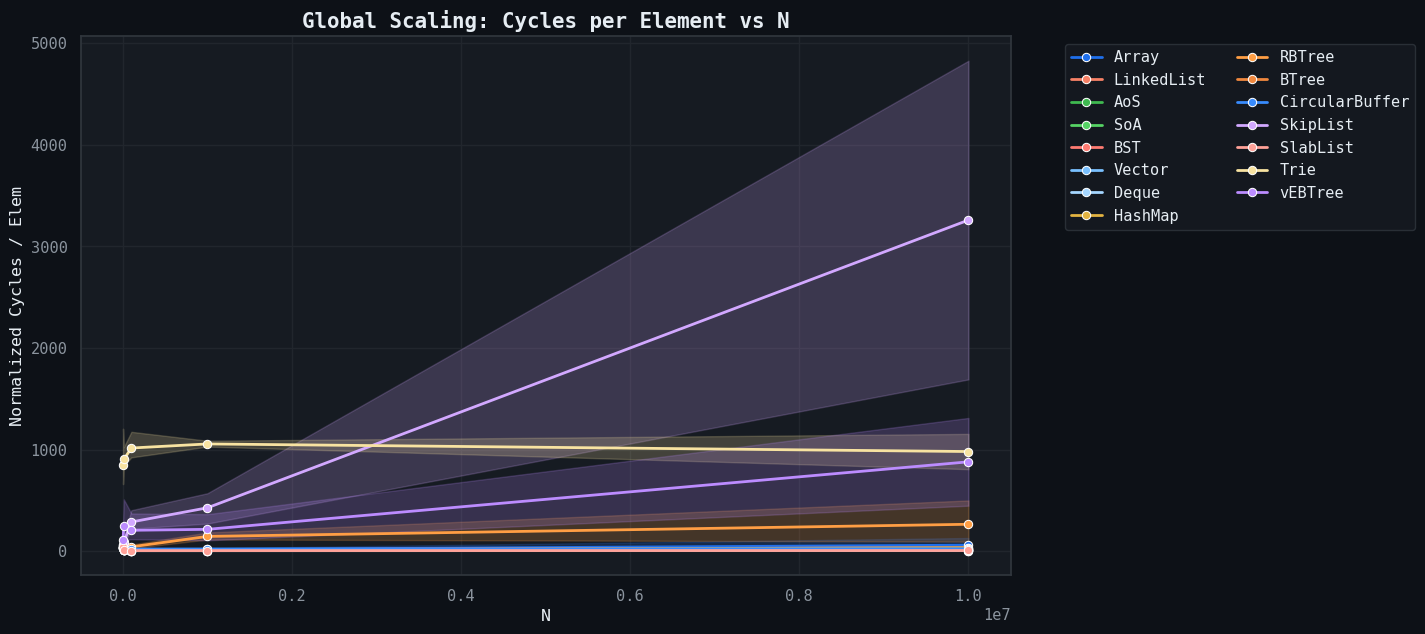

In [13]:
plt.figure(figsize=(12, 7))
palette = [COLORS.get(x, '#8b949e') for x in df['data_structure'].unique()]
sns.lineplot(data=df, x='N', y='cycles_per_elem', hue='data_structure', palette=palette, marker='o', lw=2)
plt.title("Global Scaling: Cycles per Element vs N", fontweight='bold')
plt.ylabel("Normalized Cycles / Elem")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', ncol=2)
plt.show()

## 2 · Efficiency Profiler (Cycles per Element)

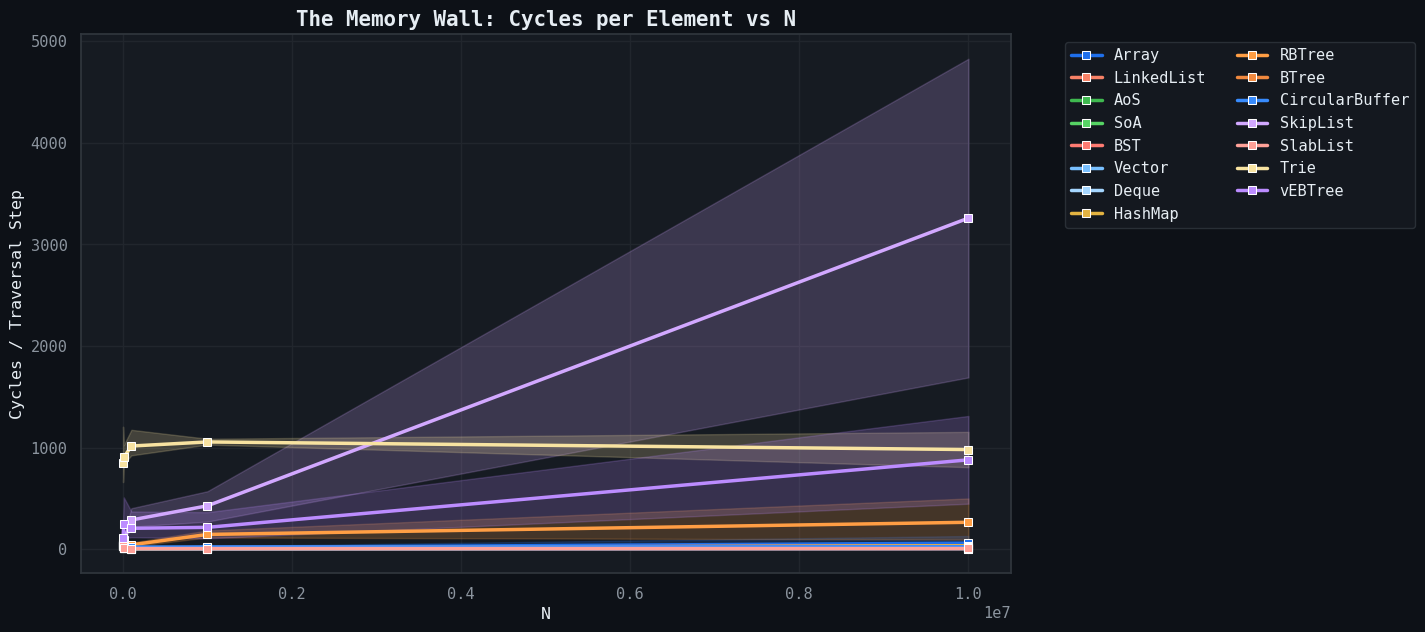

In [14]:
plt.figure(figsize=(12, 7))
palette = [COLORS.get(x, '#8b949e') for x in df['data_structure'].unique()]
sns.lineplot(data=df, x='N', y='cycles_per_elem', hue='data_structure', palette=palette, marker='s', lw=2.5)
plt.title("The Memory Wall: Cycles per Element vs N", fontweight='bold')
plt.ylabel("Cycles / Traversal Step")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', ncol=2)
plt.show()

## 3 · Bottleneck Identification: IPC vs Memory Stalls

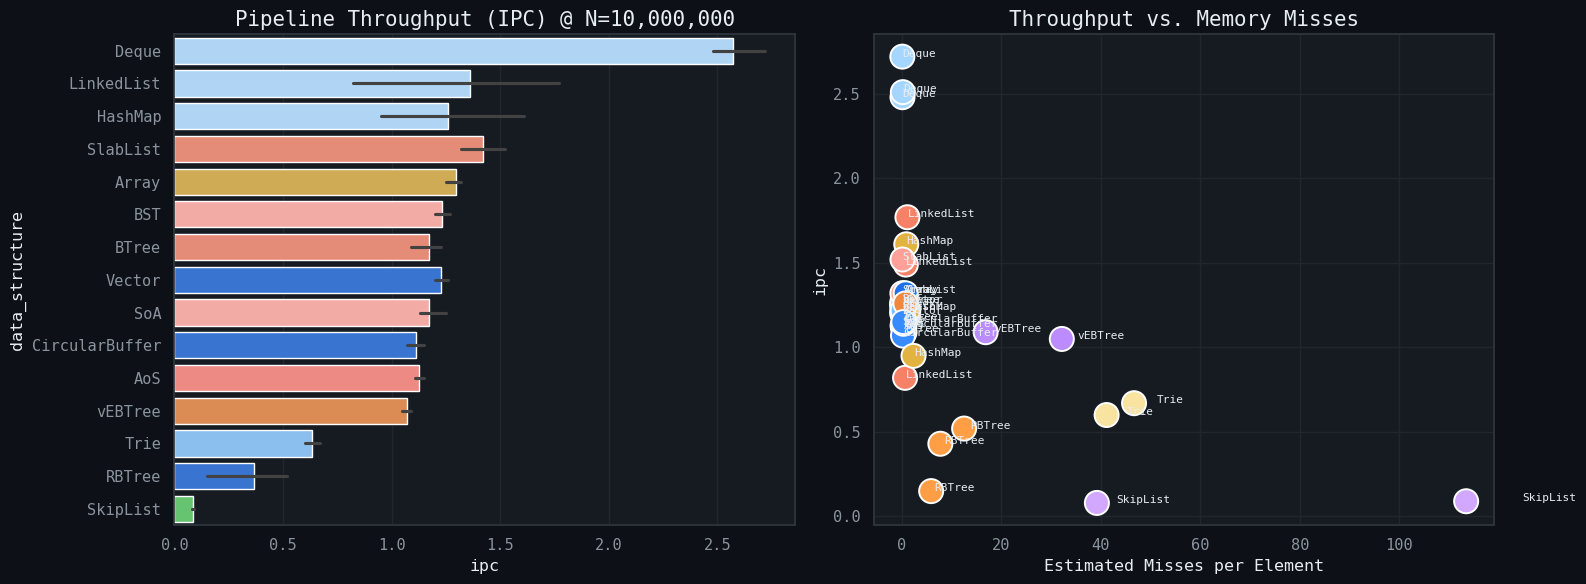

In [15]:
n_max = df['N'].max()
latest = df[df['N'] == n_max]
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
latest_sorted = latest.sort_values('ipc', ascending=False)

sns.barplot(data=latest_sorted, x='ipc', y='data_structure', 
            palette=[COLORS.get(x, '#8b949e') for x in latest_sorted['data_structure']], ax=ax1)
ax1.set_title(f"Pipeline Throughput (IPC) @ N={n_max:,}")

palette_latest = [COLORS.get(x, '#8b949e') for x in latest['data_structure'].unique()]
sns.scatterplot(data=latest, x='cm_rate', y='ipc', hue='data_structure', 
                palette=palette_latest, s=300, ax=ax2, legend=False)
for i in range(latest.shape[0]):
    ax2.text(latest.cm_rate.iloc[i]*1.1, latest.ipc.iloc[i], latest.data_structure.iloc[i], fontsize=8)
ax2.set_title("Throughput vs. Memory Misses")
ax2.set_xlabel("Estimated Misses per Element")
plt.tight_layout()
plt.show()

## 4 · Head-to-Head Comparisons

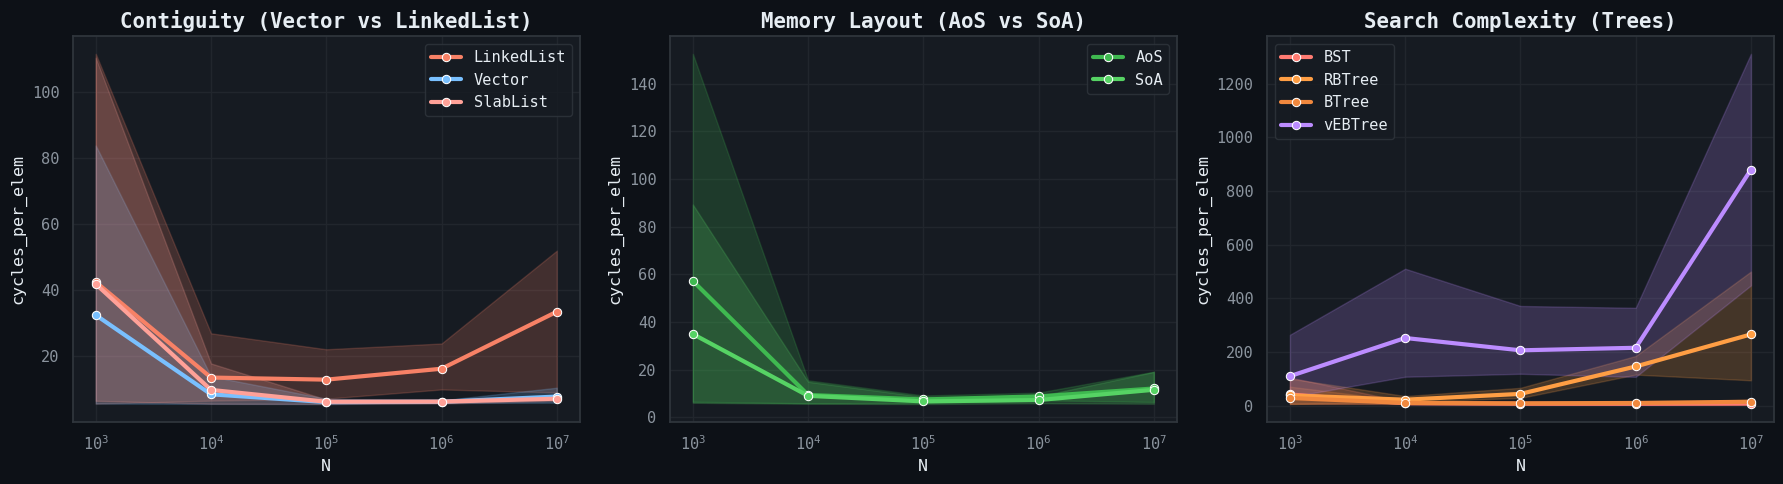

In [11]:
groups = {
    "Contiguity (Vector vs LinkedList)": ["Vector", "LinkedList", "SlabList"],
    "Memory Layout (AoS vs SoA)": ["AoS", "SoA"],
    "Search Complexity (Trees)": ["BST", "RBTree", "BTree", "vEBTree"]
}
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for i, (title, names) in enumerate(groups.items()):
    target = df[df['data_structure'].isin(names)]
    pal = [COLORS.get(x, '#8b949e') for x in target['data_structure'].unique()]
    sns.lineplot(data=target, x='N', y='cycles_per_elem', hue='data_structure', 
                 palette=pal, marker='o', ax=axes[i], lw=3)
    axes[i].set_xscale('log'); axes[i].set_title(title, fontweight='bold'); axes[i].legend(title="")
plt.tight_layout()
plt.show()

## 5 · Performance Scorecard

In [16]:
scorecard = latest[['data_structure', 'cycles_per_elem', 'ipc', 'cm_rate', 'br_miss_pct']].copy()
base_cost = scorecard['cycles_per_elem'].min()
scorecard['Relative_Cost'] = (scorecard['cycles_per_elem'] / base_cost).round(2)
scorecard = scorecard.sort_values('Relative_Cost')
scorecard.columns = ['Structure', 'Cycles/Elem', 'IPC', 'Misses/Elem', 'Branch Miss %', 'Relative Cost (x)']

def color_cost(val):
    if val == 1.0: return 'color: #3fb950; font-weight: bold'
    if val > 10.0: return 'color: #ff7b72'
    return ''

try:
    styler = scorecard.style.map(color_cost, subset=['Relative Cost (x)'])
except AttributeError:
    styler = scorecard.style.applymap(color_cost, subset=['Relative Cost (x)'])
    
display(styler.format({
    'Cycles/Elem': "{:.2f}", 'IPC': "{:.2f}", 'Relative Cost (x)': "{:.2f}x", 'Misses/Elem': "{:.2f}"
}))

,Structure,Cycles/Elem,IPC,Misses/Elem,Branch Miss %,Relative Cost (x)
34,Deque,4.79,2.72,0.10,0.006732,1.00x
19,SoA,5.66,1.25,0.10,0.019569,1.18x
24,BST,5.75,1.22,0.10,0.007128,1.20x
29,Vector,5.89,1.20,0.10,0.014728,1.23x
4,Array,6.03,1.25,0.10,0.523652,1.26x
166,BST,6.30,1.27,0.11,0.029143,1.32x
14,AoS,6.40,1.11,0.42,0.013240,1.34x
211,SlabList,6.42,1.32,0.11,0.108579,1.34x
176,Deque,6.52,2.48,0.13,0.034110,1.36x
171,Vector,6.92,1.26,0.12,0.027060,1.44x
